In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
#coffea output file
# f_sig = "../coffea/corrected_sig_2022/ERE_Xcleaned.coffea"  #with x clean and pT bounds ntuples
f_sig = "../coffea/corrected_sig_2022/ERE_removedXcleanednew.coffea"  #with x clean and pT bounds ntuples

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
[8.690e+02 1.098e+03 1.755e+03 1.675e+03 1.282e+03 9.430e+02 6.660e+02
 4.630e+02 3.130e+02 2.370e+02 1.510e+02 9.900e+01 7.000e+01 4.200e+01
 4.400e+01 2.300e+01 1.800e+01 8.000e+00 1.100e+01 7.000e+00 3.000e+00
 3.000e+00       nan 3.000e+00 1.000e+00       nan       nan 1.000e+00
       nan       nan       nan 2.000e+00 2.000e+00 1.000e+00 1.000e+00
       nan       nan 2.000e+00       nan       nan]
[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5  nan 23.5 24.5  nan  nan 27.5
  nan  nan  nan 31.5 32.5 33.5 34.5  nan  nan 37.5  nan  nan]


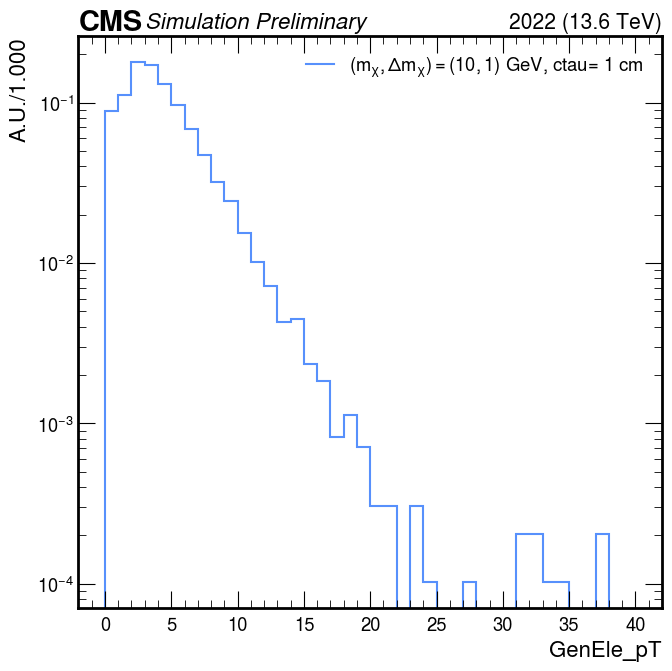

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta=0.1
ctau=10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "GenEle_pT",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}


counts, edges = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict,match_type='R', passID=1)


counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

mask = counts != 0

bins_x = (edges[:-1] + edges[ 1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)

print (counts_nonzero_den)
print (edges_nonzero_den)


#With x clean: DEN
# [7.220e+02 8.880e+02 1.360e+03 1.254e+03 9.660e+02 7.620e+02 5.560e+02
#  3.790e+02 2.640e+02 1.970e+02 1.240e+02 8.500e+01 6.300e+01 3.700e+01
#  3.700e+01 2.100e+01 1.600e+01 7.000e+00 1.100e+01 7.000e+00 3.000e+00
#  3.000e+00       nan       nan       nan       nan       nan 1.000e+00
#        nan       nan       nan 2.000e+00       nan 1.000e+00 1.000e+00
#        nan       nan 2.000e+00       nan       nan]

#REMOVE x clean: DEN
# [8.690e+02 1.098e+03 1.755e+03 1.675e+03 1.282e+03 9.430e+02 6.660e+02
#  4.630e+02 3.130e+02 2.370e+02 1.510e+02 9.900e+01 7.000e+01 4.200e+01
#  4.400e+01 2.300e+01 1.800e+01 8.000e+00 1.100e+01 7.000e+00 3.000e+00
#  3.000e+00       nan 3.000e+00 1.000e+00       nan       nan 1.000e+00
#        nan       nan       nan 2.000e+00 2.000e+00 1.000e+00 1.000e+00
#        nan       nan 2.000e+00       nan       nan]

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
[ 0.  1.  0.  4. 19. 96. 98. 70. 46. 32. 25. 17.  6.  2.  6.  1.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.
  0.  1.  0.  0.]


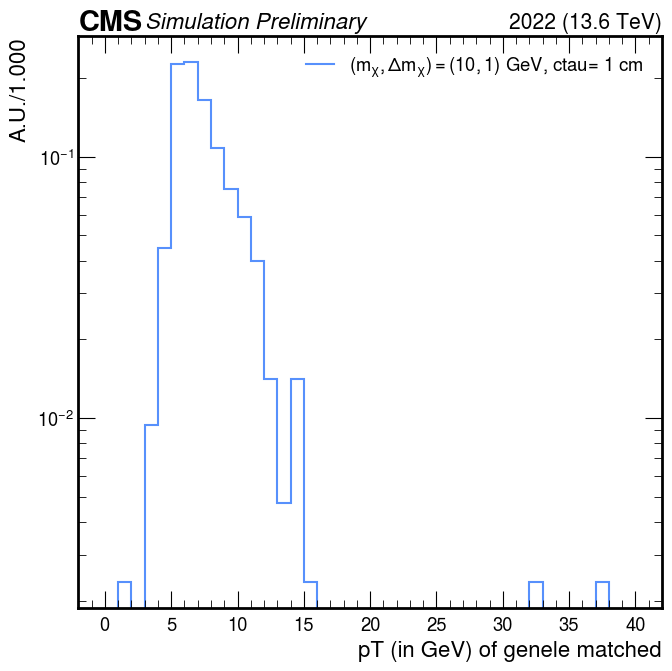

In [4]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau=10


plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV) of genele matched",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

counts, edges = ptools.plot_signal_1D_match(
        sig_histo, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )


counts_num = np.array(counts)     # shape: (n_m1, n_bins)
edges_num  = np.array(edges)      # shape: (n_m1, n_edges)

# bins_x_num = (edges_num[:, :-1] + edges_num[:, 1:])*(0.5)

bins_x_num = (edges_num[ :-1] + edges_num[ 1:])*(0.5)

print (counts_num)

#With x clean: num

# [  0.   1.   0.   2.  21. 103. 108.  86.  60.  38.  30.  15.  11.   3.
#    8.   3.   2.   2.   1.   1.   1.   0.   0.   0.   0.   0.   0.   0.
#    0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.]


#REMOVE x clean:
# [ 0.  1.  0.  4. 19. 96. 98. 70. 46. 32. 25. 17.  6.  2.  6.  1.  0.  0.
#   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.
#   0.  1.  0.  0.]

In [5]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_R, unc_eff_R = eff_determine_unc(counts_num, counts_nonzero_den)

print (efficiency_R)
print (unc_eff_R)





[0.         0.00091075 0.         0.00238806 0.01482059 0.10180276
 0.14714715 0.1511879  0.14696486 0.1350211  0.16556291 0.17171717
 0.08571429 0.04761905 0.13636364 0.04347826 0.         0.
 0.         0.         0.         0.                nan 0.
 0.                nan        nan 0.                nan        nan
        nan 0.         0.5        0.         0.                nan
        nan 0.5               nan        nan]
[[0.00000000e+00 7.53424235e-04 0.00000000e+00 1.14254889e-03
  3.35500212e-03 9.93283118e-03 1.39147979e-02 1.69180871e-02
  2.03789181e-02 2.26056412e-02 3.10420595e-02 3.90703790e-02
  3.34716892e-02 3.06976105e-02 5.27264563e-02 3.59953643e-02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00            nan 0.00000000e+00
  0.00000000e+00            nan            nan 0.00000000e+00
             nan            nan            nan 0.00000000e+00
  4.17248465e-01 0.00000000e+00 0.00000000e+00            nan
          

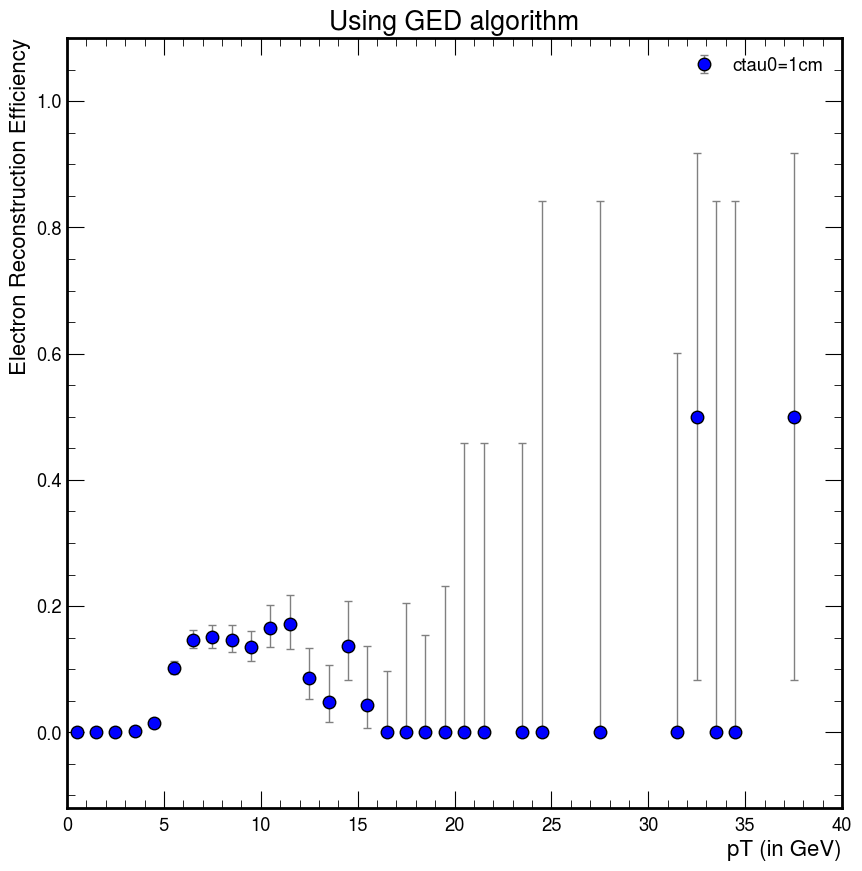

In [6]:
# plt.errorbar(
#     bins_x[0], efficiency_R[0],
#     yerr=unc_eff_R[:,0,:] ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=10 GeV'  
# )

plt.errorbar(
    bins_x, efficiency_R,
    yerr=unc_eff_R ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='ctau0=1cm'  
)

# plt.errorbar(
#     bins_x[1], efficiency_R[1],
#     yerr=unc_eff_R[1,:,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='ctau0=10cm'  
# )


# plt.errorbar(
#     bins_x[1], efficiency_R[1],
#     yerr=unc_eff_R[:,1,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=20 GeV'  
# )

# plt.errorbar(
#     bins_x[2], efficiency_R[2],
#     yerr=unc_eff_R[:,2,:] ,fmt='o', markersize=9, markerfacecolor='yellow', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=30 GeV'  
# )


# plt.errorbar(
#     bins_x[3], efficiency_R[3],
#     yerr=unc_eff_R[:,3,:] ,fmt='o', markersize=9, markerfacecolor='purple', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=50 GeV'  
# )


plt.ylim(-0.12,1.1)
plt.xlim(0,40)
plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title("Using GED algorithm")
plt.legend(loc='upper right')
plt.savefig("pt510.png")